In [29]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# mpl.rc('font', family='serif', serif='cmr10', size=10)
mpl.rc('font', family='times new roman', size=12)
plt.rcParams['axes.unicode_minus'] = False

In [30]:
import pandas as pd
df0 = pd.read_csv('p_grid_results_price.csv',sep=',')
df0

,h,s,p_grid,omega,p_wt,p_el,p_comp,m_in,m_out,m_tank
0,1,1,644.314667,1036.9096,594.054829,1211.422138,26.947359,24276.899640,0.00000,24276.899640
1,1,2,901.448891,1250.2617,690.011069,1556.829228,34.630732,31198.857730,25000.00000,6198.857727
2,1,3,0.000000,96.7304,380.713521,372.429060,8.284461,7463.478355,0.00000,7463.478355
3,2,1,359.660276,709.8297,516.126081,856.728936,19.057421,17168.847880,25000.00000,16445.747520
4,2,2,619.828807,749.2752,612.756753,1205.764062,26.821498,24163.511790,25000.00000,5362.369522
...,...,...,...,...,...,...,...,...,...,...
499,167,2,640.833064,988.0429,613.101210,1226.648221,27.286054,24582.030340,25000.00000,169.549190
500,167,3,0.000000,0.0000,419.823481,410.687973,9.135508,8230.186980,0.00000,8230.186980
501,168,1,0.000000,477.7642,671.486873,656.875081,14.611792,13163.776620,25000.00000,0.000000
502,168,2,648.639250,1062.7962,617.967002,1239.044452,27.561800,24830.450810,25000.00000,0.000000


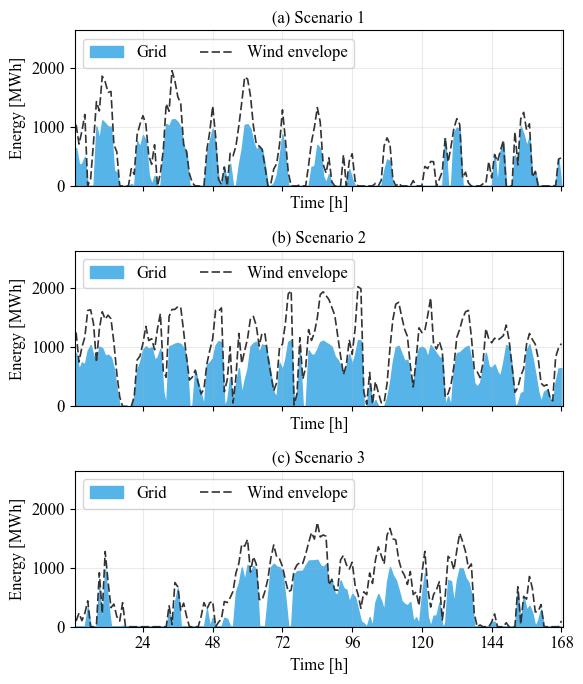

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure numeric
df0["h"] = pd.to_numeric(df0["h"], errors="raise")
df0["s"] = pd.to_numeric(df0["s"], errors="raise")
df0["p_grid"] = pd.to_numeric(df0["p_grid"], errors="raise")
df0["omega"] = pd.to_numeric(df0["omega"], errors="raise")

scenarios = sorted(df0["s"].unique())
if len(scenarios) != 3:
    print(f"Warning: expected 3 scenarios, found {len(scenarios)} -> {scenarios}")

# Common y-limits for fair comparison
ymax = np.nanmax([df0["p_grid"].max(), df0["omega"].max()])
ymin = 0.0

# X ticks every 24 h
xmin = df0["h"].min()
xmax = df0["h"].max()
xticks = np.arange(int(np.floor(xmin / 24)) * 24, int(np.ceil(xmax / 24)) * 24 + 1, 24)

fig, axes = plt.subplots(
    nrows=len(scenarios), ncols=1,
    figsize=(6, 7.0),
    sharex=True, sharey=True
)

if len(scenarios) == 1:
    axes = [axes]

for idx, (ax, s) in enumerate(zip(axes, scenarios)):
    d = df0[df0["s"] == s].sort_values("h")

    ax.fill_between(d["h"], 0, d["p_grid"], label="Grid", color="#56B4E9")
    ax.plot(d["h"], d["omega"], linestyle=(0, (5, 2)), linewidth=1.2, label="Wind envelope", color="#333333")


    ax.set_ylim(ymin, ymax*1.3)
    ax.set_xticks(xticks)
    ax.set_xlabel("Time [h]")
    ax.set_xlim(xmin - 0.5, xmax + 0.5)
    ax.set_ylabel("Energy [MWh]")
    ax.grid(True, axis="both", alpha=0.25)
    ax.legend(loc="upper left", fontsize=12, ncols=2)
    panel = chr(ord("a") + idx)
    ax.set_title(f"({panel}) Scenario {int(s)}", loc="center", fontsize=12)

axes[-1].set_xlabel("Time [h]")

plt.tight_layout()
plt.savefig("grid_power_comparison.pdf", bbox_inches="tight")
plt.show()


In [32]:
import pandas as pd
import numpy as np

# -----------------------------
# Settings
# -----------------------------
EPS = 1e-9          # treat omega <= EPS as zero
BIND_THR = 0.99     # binding if p_grid >= 0.99 * omega


# Ensure numeric
for col in ["h", "s", "p_grid", "omega"]:
    df0[col] = pd.to_numeric(df0[col], errors="raise")

# -----------------------------
# Compute metrics
# -----------------------------
df0["util_ratio"] = np.where(df0["omega"] > EPS, df0["p_grid"] / df0["omega"], np.nan)
df0["binding"] = (df0["omega"] > EPS) & (df0["p_grid"] >= BIND_THR * df0["omega"])
df0["slack"] = np.where(df0["omega"] > EPS, df0["omega"] - df0["p_grid"], np.nan)

rows = []
for s, d in df0.groupby("s"):
    d = d[d["omega"] > EPS]
    rows.append({
        "scenario": int(s),
        "binding_freq_%": 100.0 * d["binding"].mean(),
        "avg_envelope_util_%": 100.0 * d["util_ratio"].mean(),
        "p95_util_%": 100.0 * d["util_ratio"].quantile(0.95),
        "avg_slack_MW": d["slack"].mean(),
    })

metrics_df = pd.DataFrame(rows).sort_values("scenario")

overall = pd.Series({
    "binding_freq_%": 100.0 * df0.loc[df0["omega"] > EPS, "binding"].mean(),
    "avg_envelope_util_%": 100.0 * df0.loc[df0["omega"] > EPS, "util_ratio"].mean(),
    "p95_util_%": 100.0 * df0.loc[df0["omega"] > EPS, "util_ratio"].quantile(0.95),
    "avg_slack_MW": df0.loc[df0["omega"] > EPS, "slack"].mean(),
}, name="overall")

print("Per-scenario metrics:")
print(metrics_df.round(2).to_string(index=False))

print("\nOverall metrics:")
print(overall.round(2).to_string())

# Optional: save
metrics_df.to_csv("envelope_metrics_by_scenario.csv", index=False)
overall.to_frame().T.to_csv("envelope_metrics_overall.csv", index=False)

Per-scenario metrics:
 scenario  binding_freq_%  avg_envelope_util_%  p95_util_%  avg_slack_MW
        1            8.40                44.34      100.00        282.30
        2            6.71                61.15       99.87        346.71
        3            2.31                44.11       94.56        330.75

Overall metrics:
binding_freq_%           5.81
avg_envelope_util_%     50.94
p95_util_%              99.90
avg_slack_MW           323.13


In [33]:
# Total grid power (sum of p_grid) per scenario
total_grid_power = df0.groupby("s")["p_grid"].sum()
total_grid_power

s
1     47479.704080
2    106301.506431
3     56128.581007
Name: p_grid, dtype: float64

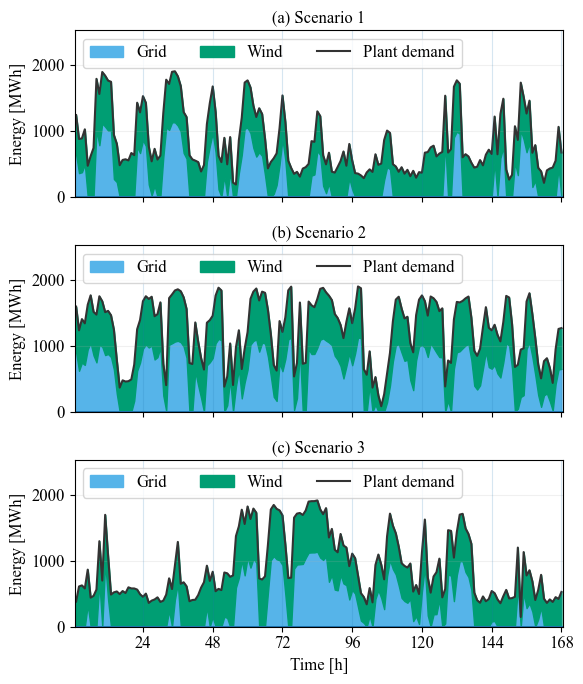

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# --- assumes df0 has columns: h, s, p_grid, p_wt, p_el, p_comp ---
scenarios = sorted(df0["s"].unique())

fig, axes = plt.subplots(
    nrows=len(scenarios), ncols=1,
    figsize=(6, 7),
    sharex=True, sharey=True
)

if len(scenarios) == 1:
    axes = [axes]

# Consistent styling
BAR_W = 0.7
DAY = 24

for idx, (ax, s) in enumerate(zip(axes, scenarios)):
    d = df0[df0["s"] == s].sort_values("h").copy()

    h = d["h"].to_numpy()

    # Supply (positive)
    grid = d["p_grid"].to_numpy()
    wind = d["p_wt"].to_numpy()

    # Demand (plotted negative for readability)
    el = d["p_el"].to_numpy()
    comp = d["p_comp"].to_numpy()

    # ---- Positive stack: Grid + Wind ----
    ax.fill_between(h, 0, grid, label="Grid", color="#56B4E9")
    ax.fill_between(h, grid, grid + wind, label="Wind",  color="#009E73")

    # ---- Negative stack: Electrolyzer + Compressor ----
    ax.plot(h, el + comp, label="Plant demand", linewidth= 1.5, color="#333333")
    
    # Emphasize the zero line
    ax.axhline(0, linewidth=1.4)

    # Day separators (every 24 h)
    hmin = int(np.floor(h.min()))
    hmax = int(np.ceil(h.max()))
    day_marks = np.arange((hmin // DAY + 1) * DAY, hmax + 1, DAY)
    for dm in day_marks:
        ax.axvline(dm, linewidth=0.8, alpha=0.18)

    # Cosmetics
    ax.set_ylabel("Energy [MWh]")
    ax.grid(True, axis="y", alpha=0.18)
    ax.grid(False, axis="x")
    ax.legend(loc="upper left", fontsize=12, ncol=3)
    panel = chr(ord("a") + idx)
    ax.set_title(f"({panel}) Scenario {int(s)}", fontsize=12)


# X ticks every 24 h
xmin = df0["h"].min()
xmax = df0["h"].max()
xticks = np.arange(int(np.floor(xmin / DAY)) * DAY, int(np.ceil(xmax / DAY)) * DAY + 1, DAY)
axes[-1].set_xticks(xticks)
axes[-1].set_xlabel("Time [h]")
axes[-1].set_xlim(xmin - 0.5, xmax + 0.5)

# Shared y-lims (keeps comparability)
pos_max = (df0["p_grid"] + df0["p_wt"]).max()
ymax = np.ceil(pos_max / 250) * 250 *1.26
ymin = 0
for ax in axes:
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.savefig("power_supply_demand_stack.pdf", bbox_inches="tight")
plt.show()


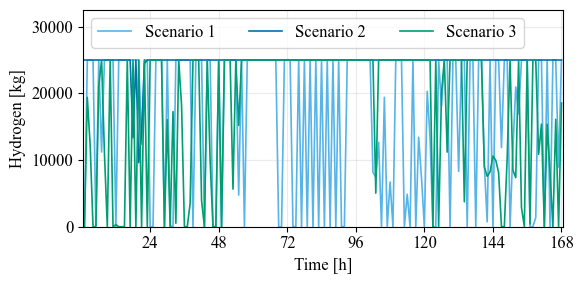

In [35]:
# Common y-limits for fair comparison
ymax = df0["m_out"].max()
ymin = 0.0

# Set specific colors per curve
curve_colors = {
    "Scenario 1": "#56B4E9",  # Sky Blue (Matches Grid Import)
    "Scenario 2": "#0072B2",  # Deep Blue (Distinct anchor)
    "Scenario 3": "#009E73",  # Bluish Green (Matches Wind Energy)
}

fig, ax = plt.subplots(figsize=(6, 3))

for s in scenarios:
    d = df0[df0["s"] == s].sort_values("h")
    label = f"Scenario {int(s)}"
    color = curve_colors.get(label, None)
    ax.plot(d["h"], d["m_out"], linestyle="-", linewidth=1.2,
            label=label, color=color)

ax.set_xticks(xticks)
ax.set_xlabel("Time [h]")
ax.set_xlim(xmin - 0.5, xmax + 0.5)
ax.set_ylim(ymin, ymax * 1.3)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Hydrogen [kg]")
ax.grid(True, axis="both", alpha=0.25)
ax.legend(ncol=3, loc="upper left")

plt.tight_layout()
plt.savefig("hydrogen_market_all_scenarios.pdf", bbox_inches="tight")
plt.show()


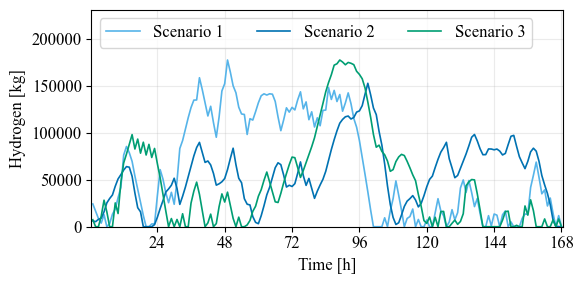

In [36]:
# Common y-limits for fair comparison
ymax = df0["m_tank"].max()
ymin = 0.0

# Set specific colors per curve
curve_colors = {
    "Scenario 1": "#56B4E9",  # Sky Blue (Matches Grid Import)
    "Scenario 2": "#0072B2",  # Deep Blue (Distinct anchor)
    "Scenario 3": "#009E73",  # Bluish Green (Matches Wind Energy)
}

fig, ax = plt.subplots(figsize=(6, 3))

for s in scenarios:
    d = df0[df0["s"] == s].sort_values("h")
    label = f"Scenario {int(s)}"
    color = curve_colors.get(label, None)
    ax.plot(d["h"], d["m_tank"], linestyle="-", linewidth=1.2,
            label=label, color=color)

ax.set_xticks(xticks)
ax.set_xlabel("Time [h]")
ax.set_xlim(xmin - 0.5, xmax + 0.5)
ax.set_ylim(ymin, ymax * 1.3)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Hydrogen [kg]")
ax.grid(True, axis="both", alpha=0.25)
ax.legend(ncol=3, loc="upper left")

plt.tight_layout()
plt.savefig("hydrogen_tank_all_scenarios.pdf", bbox_inches="tight")
plt.show()


In [37]:
import pandas as pd
df1 = pd.read_csv('wind_profiles.csv',sep=',')
df1

,h,Scenario 1,Scenario 2,Scenario 3
0,1,0.858473,0.900416,0.912490
1,2,0.869290,0.801976,0.738599
2,3,0.960896,0.906306,0.660693
3,4,0.993691,0.961616,0.734159
4,5,0.785778,0.984375,0.813699
...,...,...,...,...
163,164,0.401486,0.717599,0.689430
164,165,0.506182,0.734029,0.572504
165,166,0.372308,0.878156,0.603768
166,167,0.480332,0.910871,0.582398


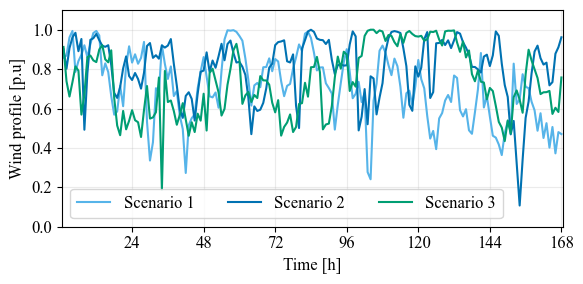

In [38]:
# Detect a likely time column (if present)
hour_candidates = [c for c in df1.columns if str(c).strip().lower() in ("h", "hour", "hours", "time")]
hour_col = hour_candidates[0] if hour_candidates else None

# Build x-axis from time column, otherwise use row index
x = pd.to_numeric(df1[hour_col], errors="coerce") if hour_col else pd.Series(range(len(df1)), index=df1.index)

# Set specific colors per curve
curve_colors = {
    "Scenario 1": "#56B4E9",  # Sky Blue (Matches Grid Import)
    "Scenario 2": "#0072B2",  # Deep Blue (Distinct anchor)
    "Scenario 3": "#009E73",  # Bluish Green (Matches Wind Energy)
}

fig = plt.figure(figsize=(6, 3))
for c in df1.columns:
    if c == hour_col:
        continue
    y = pd.to_numeric(df1[c], errors="coerce")
    plt.plot(x, y, label=c, color=curve_colors.get(c, "#333333"))

plt.xlabel("Time [h]" if hour_col else "Index")
plt.ylabel("Wind profile [p.u]")
plt.xticks(xticks)
plt.xlabel("Time [h]")
plt.xlim(xmin - 0.5, xmax + 0.5)
plt.ylim(0, 1.1)
plt.legend(ncol=3, loc="lower left")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("wind_profiles.pdf", bbox_inches="tight")
plt.show()

In [39]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla

# =========================
# Power tracing (proportional sharing) for wind-to-plant attribution
# Inputs (CSVs): trace_lines, trace_flows, trace_wind, trace_thermal_bus, trace_plant, trace_pi
# Output: wind_unit_contribution_to_plant.csv (+ optional full source table)
# =========================

# -------------------------
# Load exported CSVs
# -------------------------
lines = pd.read_csv("trace_lines.csv")              # i,j
flows = pd.read_csv("trace_flows.csv")              # i,j,h,s,f_mw
wind  = pd.read_csv("trace_wind.csv")               # w,bus,zone,h,s,net_mw (net after curtailment)
therm = pd.read_csv("trace_thermal_bus.csv")        # i,h,s,pT_mw (thermal injection at bus i)
plant = pd.read_csv("trace_plant.csv")              # k,h,s,yD,pplant_mw
pi_df = pd.read_csv("trace_pi.csv")                 # s,pi

# Basic types
for df in (flows, wind, therm, plant, pi_df):
    for c in ("h", "s"):
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="raise").astype(int)
for c in ("i", "j"):
    flows[c] = pd.to_numeric(flows[c], errors="raise").astype(int)
lines["i"] = pd.to_numeric(lines["i"], errors="raise").astype(int)
lines["j"] = pd.to_numeric(lines["j"], errors="raise").astype(int)

flows["f_mw"] = pd.to_numeric(flows["f_mw"], errors="raise").astype(float)
wind["w"] = pd.to_numeric(wind["w"], errors="raise").astype(int)
wind["bus"] = pd.to_numeric(wind["bus"], errors="raise").astype(int)
wind["zone"] = pd.to_numeric(wind["zone"], errors="coerce")
wind["net_mw"] = pd.to_numeric(wind["net_mw"], errors="raise").astype(float)

therm["i"] = pd.to_numeric(therm["i"], errors="raise").astype(int)
therm["pT_mw"] = pd.to_numeric(therm["pT_mw"], errors="raise").astype(float)

plant["k"] = pd.to_numeric(plant["k"], errors="raise").astype(int)
plant["yD"] = pd.to_numeric(plant["yD"], errors="raise").astype(int)
plant["pplant_mw"] = pd.to_numeric(plant["pplant_mw"], errors="coerce").fillna(0.0).astype(float)

pi_s = dict(zip(pi_df["s"].astype(int), pi_df["pi"].astype(float)))

# -------------------------
# Sets and indices
# -------------------------
buses = sorted(set(flows["i"]).union(set(flows["j"])))
bus_to_idx = {b: idx for idx, b in enumerate(buses)}
n = len(buses)

line_list = list(zip(lines["i"].tolist(), lines["j"].tolist()))
L = len(line_list)

# Plant bus (chosen location)
chosen = plant.loc[plant["yD"] == 1, "k"].unique()
if len(chosen) != 1:
    raise ValueError(f"Expected exactly one chosen plant bus (yD=1), got: {chosen}")
plant_bus = int(chosen[0])
k_idx = bus_to_idx[plant_bus]

# Plant load only at chosen bus
plant_chosen = plant[plant["k"] == plant_bus][["h", "s", "pplant_mw"]].copy()
plant_chosen = plant_chosen[plant_chosen["pplant_mw"] > 1e-9]

# Wind metadata for reporting
w_meta = (
    wind.dropna(subset=["w", "bus"])
        .groupby("w")[["bus", "zone"]]
        .first()
)
w_to_bus = w_meta["bus"].astype(int).to_dict()
w_to_zone = w_meta["zone"].fillna(-1).astype(int).to_dict()

# -------------------------
# Pre-index flows / injections by (h,s) for speed
# -------------------------
# Flows: dict[(h,s)] -> array f_vals aligned with line_list
flows_map = {}
for (h, s), df_hs in flows.groupby(["h", "s"]):
    fm = {(int(r.i), int(r.j)): float(r.f_mw) for r in df_hs.itertuples(index=False)}
    flows_map[(int(h), int(s))] = np.array([fm[(i, j)] for (i, j) in line_list], dtype=float)

# Wind: dict[(h,s)] -> list of (w_id, bus_id, net_mw)
wind_map = {}
for (h, s), df_hs in wind.groupby(["h", "s"]):
    rows = [(int(r.w), int(r.bus), float(r.net_mw)) for r in df_hs.itertuples(index=False)]
    wind_map[(int(h), int(s))] = rows

# Thermal: dict[(h,s)] -> list of (bus_id, pT_mw)
therm_map = {}
for (h, s), df_hs in therm.groupby(["h", "s"]):
    rows = [(int(r.i), float(r.pT_mw)) for r in df_hs.itertuples(index=False)]
    therm_map[(int(h), int(s))] = rows

# -------------------------
# Helper: build directed in-edges/out-edges from signed flows
# -------------------------
def build_directed_edges(f_vals: np.ndarray):
    out_edges = {b: [] for b in buses}
    in_edges  = {b: [] for b in buses}
    for (i, j), f in zip(line_list, f_vals):
        f = float(f)
        if f >= 0:
            a, b, p = i, j, f
        else:
            a, b, p = j, i, -f
        if p > 1e-12:
            out_edges[a].append((b, p))
            in_edges[b].append((a, p))
    return out_edges, in_edges

# -------------------------
# Core tracing routine
# -------------------------
def trace_contributions(include_thermal: bool = True,
                        delta_h: float = 1.0,
                        eps: float = 1e-12):
    """
    Proportional-sharing tracing optimized with scipy.sparse.
    """
    wind_sources = sorted(wind["w"].unique())
    therm_sources = sorted(therm["i"].unique()) if include_thermal else []
    sources = [("wind", int(w)) for w in wind_sources] + [("thermal", int(i)) for i in therm_sources]
    src_to_idx = {src: j for j, src in enumerate(sources)}
    m = len(sources)

    E_src = np.zeros(m)
    E_plant = 0.0

    for (h, s), grp in plant_chosen.groupby(["h", "s"]):
        h = int(h); s = int(s)
        p_plant = float(grp["pplant_mw"].iloc[0])
        prob = float(pi_s[s])

        f_vals = flows_map.get((h, s))
        if f_vals is None:
            raise ValueError(f"Missing flows for (h={h}, s={s}).")

        out_edges, in_edges = build_directed_edges(f_vals)

        # Line inflow/outflow totals
        inflow_lines = np.zeros(n)
        outflow_lines = np.zeros(n)
        for b in buses:
            bi = bus_to_idx[b]
            inflow_lines[bi] = sum(p for (_, p) in in_edges[b])
            outflow_lines[bi] = sum(p for (_, p) in out_edges[b])

        # Local generation totals
        gen_wind_bus = np.zeros(n)
        for (w_id, b_id, p) in wind_map.get((h, s), []):
            if p > 1e-9:
                gen_wind_bus[bus_to_idx[b_id]] += p

        gen_therm_bus = np.zeros(n)
        if include_thermal:
            for (b_id, p) in therm_map.get((h, s), []):
                if p > 1e-9:
                    gen_therm_bus[bus_to_idx[b_id]] += p

        gen_total_bus = gen_wind_bus + gen_therm_bus

        # Infer demand by nodal balance
        demand_bus = inflow_lines + gen_total_bus - outflow_lines
        if demand_bus.min() < -1e-6:
            raise ValueError(f"Large negative inferred demand at (h={h}, s={s}); min={demand_bus.min():.3e}")
        demand_bus = np.where(demand_bus < 0, 0.0, demand_bus)

        # Throughput denominator
        P_T = outflow_lines + demand_bus
        P_T_safe = np.where(P_T > eps, P_T, 1.0)

        # --- OPTIMIZATION START: Build Sparse A Matrix ---
        row_A, col_A, data_A = [], [], []
        for b in buses:
            i_idx = bus_to_idx[b]
            denom = P_T_safe[i_idx]
            for (src, p) in in_edges[b]:
                j_idx = bus_to_idx[src]
                row_A.append(i_idx)
                col_A.append(j_idx)
                data_A.append(p / denom)
        
        A_sparse = sp.csc_matrix((data_A, (row_A, col_A)), shape=(n, n))

        # --- OPTIMIZATION START: Build Sparse B Matrix ---
        row_B, col_B, data_B = [], [], []
        
        for (w_id, b_id, p) in wind_map.get((h, s), []):
            if p > 1e-9:
                bi = bus_to_idx[b_id]
                sj = src_to_idx[("wind", int(w_id))]
                row_B.append(bi)
                col_B.append(sj)
                data_B.append(p / P_T_safe[bi])

        if include_thermal:
            for (b_id, p) in therm_map.get((h, s), []):
                if p > 1e-9:
                    bi = bus_to_idx[b_id]
                    sj = src_to_idx[("thermal", int(b_id))]
                    row_B.append(bi)
                    col_B.append(sj)
                    data_B.append(p / P_T_safe[bi])

        # B is typically tall and skinny, CSC format is efficient for solving
        B_sparse = sp.csc_matrix((data_B, (row_B, col_B)), shape=(n, m))

        # Solve (I - A) X = B using sparse solver
        I_minus_A = sp.eye(n, format='csc') - A_sparse

        try:
            # spsolve handles CSR matrices much faster than dense solvers
            X_sparse = spla.spsolve(I_minus_A, B_sparse)
            # Convert back to dense array for the specific plant bus row
            X_row = X_sparse[k_idx, :].toarray().flatten() if sp.issparse(X_sparse) else X_sparse[k_idx, :]
        except RuntimeError:
            # Fallback: iterative method if matrix is singular
            X_row = np.zeros(m)
            # You can keep your fixed-point iteration here if desired, 
            # though it's rare to fail with DC OPF results unless the grid is fully islanded.
            print(f"Warning: Sparse solve failed for h={h}, s={s}")

        # Contribution at plant bus
        mw_from_src = X_row * p_plant

        # Expected energy accumulation
        E_src += prob * delta_h * mw_from_src
        E_plant += prob * delta_h * p_plant

    # Build output
    contrib = pd.DataFrame({
        "source_type": [t for (t, _) in sources],
        "source_id":   [sid for (_, sid) in sources],
        "wind_bus":    [w_to_bus.get(sid, np.nan) if t == "wind" else np.nan for (t, sid) in sources],
        "zone":        [w_to_zone.get(sid, np.nan) if t == "wind" else np.nan for (t, sid) in sources],
        "E_to_plant_MWh": E_src
    })
    contrib["share_%"] = 100.0 * contrib["E_to_plant_MWh"] / E_plant if E_plant > 0 else 0.0
    contrib = contrib.sort_values("share_%", ascending=False).reset_index(drop=True)
    return contrib, E_plant

# -------------------------
# Run tracing
# -------------------------
contrib_full, E_plant = trace_contributions(include_thermal=True)

print("Chosen plant bus:", plant_bus)
print("Expected plant energy (MWh):", E_plant)
print(contrib_full.head(15))

# Wind-only export (shares of TOTAL plant energy)
wind_only = contrib_full[contrib_full["source_type"] == "wind"].copy()
wind_only = wind_only.sort_values("E_to_plant_MWh", ascending=False).reset_index(drop=True)
wind_only.to_csv("wind_unit_contribution_to_plant.csv", index=False)

# Optional: full table (wind + thermal) for diagnostics
contrib_full.to_csv("source_contribution_to_plant.csv", index=False)

# Quick totals
wind_E = wind_only["E_to_plant_MWh"].sum()
therm_E = contrib_full.loc[contrib_full["source_type"]=="thermal", "E_to_plant_MWh"].sum()
print(f"Wind share of plant energy:    {100*wind_E/E_plant:.2f}%")
print(f"Thermal share of plant energy: {100*therm_E/E_plant:.2f}%")
print(f"Check (wind+thermal):          {100*(wind_E+therm_E)/E_plant:.2f}%")

Chosen plant bus: 96
Expected plant energy (MWh): 62608.94340833085
   source_type  source_id  wind_bus  zone  E_to_plant_MWh    share_%
0         wind         85      85.0   3.0    11939.657091  19.070210
1         wind         91      91.0   3.0    10572.561598  16.886664
2         wind        104     104.0   3.0    10350.961376  16.532720
3         wind        105     105.0   3.0     7133.920308  11.394411
4         wind         99      99.0   3.0     6839.159533  10.923614
5         wind        110     110.0   3.0     5779.143627   9.230540
6         wind         90      90.0   3.0     5252.738694   8.389758
7         wind         76      76.0   3.0     2530.769241   4.042185
8         wind         70      70.0   2.0      816.907340   1.304777
9         wind         72      72.0   2.0      639.473318   1.021377
10        wind         73      73.0   2.0      541.634803   0.865108
11        wind         24      24.0   1.0      212.016479   0.338636
12     thermal         78       NaN